In [1]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from tqdm import tqdm 
import matplotlib.pyplot as plt

In [2]:
# Strain path generator

from Strain_curve_generator import strain_curve_generator

# Dataset sizes
su = 80000 # total number of generated data before modification
domain = 0.2


# Data containers
X_total = [np.zeros((6, 100)) for _ in range(su)]

# Generate full dataset
for i in range(su):
    x, y, z    = strain_curve_generator(domain , 'normal')
    xy, xz, yz = strain_curve_generator(domain , 'shear')
    X_total[i][0, :] = x
    X_total[i][1, :] = y
    X_total[i][2, :] = z
    X_total[i][3, :] = xy
    X_total[i][4, :] = xz
    X_total[i][5, :] = yz

print('X_total =', np.shape(X_total))


X_total = (80000, 6, 100)


In [3]:
# stress and damage calculator
from Path_Modifier import modifier_default

# choose your material
Materials = ['Steel' , 'Aluminum_AA7075_T6', 'Aluminum_notched_bar', 'Aluminum_flat_grooved']

material = Materials[0]

X_total_mod , Y_total_mod , num_total_data  = modifier_default(X_total , su , material)


N = 2790
num_total_data = 2000


In [ ]:
# pip install ipympl

#%matplotlib widget
#%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'Times New Roman'

fig = plt.figure()
fig.patch.set_facecolor('white')  # White figure background

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')         # White axes background

# Set pane colors (these are the gray side panels in 3D)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))  # White
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))  # White
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))  # White

# Make grid lines thinner
ax.xaxis._axinfo['grid']['linewidth'] = 0.1
ax.yaxis._axinfo['grid']['linewidth'] = 0.1
ax.zaxis._axinfo['grid']['linewidth'] = 0.1

# Optional: remove pane borders
# ax.xaxis._axinfo["grid"]['color'] = (0, 0, 0, 0)
# ax.yaxis._axinfo["grid"]['color'] = (0, 0, 0, 0)
# ax.zaxis._axinfo["grid"]['color'] = (0, 0, 0, 0)

# Plot only points (no curves)
# for i in range(2000):
#     x, y, z    = strain_curve_generator(domain , 'normal')
#     ax.plot(x, y, z, linewidth=0.4)

plt.cla()
for i in range(np.shape(X_total_mod)[0]):
    x = X_total_mod[i][0, :] 
    y = X_total_mod[i][1, :] 
    z = X_total_mod[i][2, :]
    ax.plot(x, y, z, linewidth=0.3)

# Labels
ax.set_xlabel(r'$\varepsilon_{\mathrm{xx}}$', fontsize=30, labelpad=20)
ax.set_ylabel(r'$\varepsilon_{yy}$', fontsize=30, labelpad=20)
ax.set_zlabel(r'$\varepsilon_{zz}$', fontsize=30, labelpad=10)

# Set tick font
for tick in ax.xaxis.get_major_ticks():
    tick.label1.set_fontname('Times New Roman')
for tick in ax.yaxis.get_major_ticks():
    tick.label1.set_fontname('Times New Roman')
for tick in ax.zaxis.get_major_ticks():
    tick.label1.set_fontname('Times New Roman')

xmin, xmax = -domain, domain
ymin, ymax = -domain, domain
zmin, zmax = -domain, domain

# Set axis limits
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_zlim(zmin, zmax)

# Create ticks with equal spacing
num_ticks = 5
ax.set_xticks(np.linspace(xmin, xmax, num_ticks))
ax.set_yticks(np.linspace(ymin, ymax, num_ticks))
ax.set_zticks(np.linspace(zmin, zmax, num_ticks))

ax.tick_params(axis='x', pad=5)
ax.tick_params(axis='y', pad=5)
ax.tick_params(axis='z', pad=2)

ax.grid(True)
plt.tick_params(axis='both', labelsize=10)
#plt.savefig('strain_plot_normal.svg', format='svg')  # Save as SVG
#plt.savefig('strain_plot_normalt.tif', format='tiff', bbox_inches='tight', dpi=300)
plt.show()


In [5]:
# Split into train, test, and validation


train_end = int(0.8 * num_total_data )            # 80%
test_end = train_end + int(0.1 * num_total_data ) # 10%

Y_train_mod = Y_total_mod[:train_end]
Y_test_mod  = Y_total_mod[train_end:test_end]
Y_valid_mod = Y_total_mod[test_end:num_total_data ]

X_train_mod = X_total_mod[:train_end]
X_test_mod  = X_total_mod[train_end:test_end]
X_valid_mod = X_total_mod[test_end:num_total_data ]


print('Y_train_mod = ',np.shape(Y_train_mod))
print('Y_test_mod = ',np.shape(Y_test_mod))
print('Y_valid_mod = ',np.shape(Y_valid_mod))

Y_train_mod =  (1600, 7, 100)
Y_test_mod =  (200, 7, 100)
Y_valid_mod =  (200, 7, 100)


In [6]:
# Collocation paths (for PINN)

from  Path_Modifier import modifier_PINN

PINN_domain = 0.4
du = 400000

X_pinn = [np.zeros((6, 100)) for _ in range(du)]

# Generate collocatio paths for PINN
for i in range(du):
    x, y, z    = strain_curve_generator(PINN_domain, 'normal')
    xy, xz, yz = strain_curve_generator(PINN_domain, 'shear')
    X_pinn[i][0, :] = x
    X_pinn[i][1, :] = y
    X_pinn[i][2, :] = z
    X_pinn[i][3, :] = xy
    X_pinn[i][4, :] = xz
    X_pinn[i][5, :] = yz


# stress and damage calculation
X_pinn_mod , Y_pinn_mod , num_collocation  = modifier_PINN(X_pinn, du, material)

# input normalization
# X = np.array(X_pinn_mod)
# mins = X.min(axis=2, keepdims=True)
# maxs = X.max(axis=2, keepdims=True)
# X_pinn_mod = (X - mins) / (maxs - mins + 1e-8)


print('X_pinn_mod =', np.shape(X_pinn_mod))
print('Y_pinn_mod =', np.shape(Y_pinn_mod))


N = 2030
num_collocation = 2000
X_pinn_mod = (2000, 7, 100)
Y_pinn_mod = (2000, 7, 100)


In [ ]:
# pip install ipympl

#%matplotlib widget

import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'Times New Roman'

fig = plt.figure()
fig.patch.set_facecolor('white')  # White figure background

ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')         # White axes background

# Set pane colors to white
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

# Remove grid and ticks
ax.grid(True)
# ax.set_xticks([])
# ax.set_yticks([])
# ax.set_zticks([])

xmin, xmax = -PINN_domain, PINN_domain
ymin, ymax = -PINN_domain, PINN_domain
zmin, zmax = -PINN_domain, PINN_domain

# Set axis limits
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_zlim(zmin, zmax)

# Create ticks with equal spacing
num_ticks = 5
ax.set_xticks(np.linspace(xmin, xmax, num_ticks))
ax.set_yticks(np.linspace(ymin, ymax, num_ticks))
ax.set_zticks(np.linspace(zmin, zmax, num_ticks))

# Make 3D grid lines thinner
ax.xaxis._axinfo['grid'].update({'linewidth': 0.2})
ax.yaxis._axinfo['grid'].update({'linewidth': 0.2})
ax.zaxis._axinfo['grid'].update({'linewidth': 0.2})

ax.set_xlabel(r'$\varepsilon_{\mathrm{xx}}$', fontsize=30, labelpad=20)
ax.set_ylabel(r'$\varepsilon_{yy}$', fontsize=30, labelpad=20)
ax.set_zlabel(r'$\varepsilon_{zz}$', fontsize=30, labelpad=10)

# Plot red points

# list to a NumPy array
X1 = np.array(X_pinn)[:num_collocation , 0, :].flatten()
Y1 = np.array(X_pinn)[:num_collocation , 1, :].flatten()
Z1 = np.array(X_pinn)[:num_collocation , 2, :].flatten()

# visualize modified
X = np.array(X_pinn_mod)[:, 0, :].flatten()
Y = np.array(X_pinn_mod)[:, 1, :].flatten()
Z = np.array(X_pinn_mod)[:, 2, :].flatten()


# One scatter call (much faster)
ax.scatter(X1, Y1, Z1, s=0.2, color='r')
#ax.scatter(X , Y , Z , s=0.2, color='r')
plt.tight_layout()
plt.tick_params(axis='both', labelsize=10)
#plt.savefig('strain_points_all.svg', format='svg', facecolor='white')
plt.show()


Check PINN Lossses on Data before training

In [15]:
# from DDSDDE import elastic_ddsdde_3D

# ddsdde = elastic_ddsdde_3D(210.0e9, 0.3)
# ddsdde = torch.tensor(ddsdde, dtype=torch.float64)

# X_train_tens = torch.tensor(np.array(X_train_mod), dtype=torch.float64).transpose(1, 2)  # shape: (N, T, 6)
# Y_train_tens = torch.tensor(np.array(Y_train_mod), dtype=torch.float64).transpose(1, 2)  # shape: (N, T, 8)

# batch = 65
# step = 50

# E = 210.0e9
# nu = 0.3
# G = 210e9/2.6
# BULK = E / (3 * (1 - 2 * nu))
# XR = 3.5e6
# XS = 1

# tens = X_train_tens[batch]
# depsilon_ij = X_train_tens[batch,step,:-1] - X_train_tens[batch,step-1,:-1]   # (batch, 100 , 7)
# dlanda      = X_train_tens[batch,step,6]
# dsigma_ij   = Y_train_tens[batch,step,:-1] - Y_train_tens[batch,step-1,:-1]

# LANDA = torch.cumsum(X_train_tens[batch, :,6], dim=0) # shape: [B, 100]
# landa = LANDA[step-1]  # *** 1 step behind


# sxx , syy , szz ,sxy, sxz, syz , Dn1 = Y_train_tens[batch,step,:].unbind(-1)
# Dn1 = Y_train_tens[batch,step,6]
# Dn0 = Y_train_tens[batch,step-1,6]
# OMEGA  = (1 - Dn1)
# OMEGAN = (1 - Dn0)



# sigma_eq = torch.sqrt( 0.5*( (sxx-syy)**2 + (syy-szz)**2 + (szz-sxx)**2) + 3*(sxy**2 + syz**2 + sxz**2))
# s_hyd = 1/3 * (sxx + syy + szz )
# S_ij = torch.tensor([sxx - s_hyd, syy - s_hyd, szz - s_hyd, sxy, sxz , syz ], dtype=torch.float32)



# # yield                                                  # works
# R = 3300e6 * (1 - np.exp(-0.4 * (landa + dlanda)))
# SIGMAY = 620.0e6 + R
# Ly = sigma_eq/OMEGA  - SIGMAY 
# print('Ly =', Ly)


# # damage                                                 # works
# trace_sigma = sxx + syy + szz
# sigma_dot_sigma = (sxx**2 + syy**2 + szz**2 + 2 * (sxy**2 + syz**2 + sxz**2))
# denom = 2 * E * (1 - Dn1)**2
# Y = -1.0 / denom * ((1 + nu) * sigma_dot_sigma - nu * trace_sigma**2)  # replace with UMAT formula!
# Ld = Dn1 - Dn0 - dlanda/OMEGA * ((-Y / XR) ** XS)
# print('Ld =', Ld)


# #----------------- using DDSDDE --------------------------
# sigma_ij_0 = Y_train_tens[batch,step-1,:-1]
# sigma_ij_1 = Y_train_tens[batch,step,:-1]


# F1 = sigma_ij_1 -  (1-Dn1)/(1-Dn0) * sigma_ij_0 - (1-Dn1)*ddsdde @ depsilon_ij + 3*G*dlanda *(S_ij/sigma_eq)     
# print('F1 =', F1)


# DSTRESSTR =(1-Dn0) * ddsdde @ depsilon_ij 
# STRESS = Y_train_tens[batch,step-1,:-1]
# STRESSTR =  STRESS + DSTRESSTR
# HYDSTRESSTR = torch.sum(STRESSTR[:3]) / 3

# DEVSTRESSTR = torch.zeros(6, device=STRESSTR.device)
# DEVSTRESSTR[:3] = STRESSTR[:3] - HYDSTRESSTR
# DEVSTRESSTR[3:] = STRESSTR[3:]
# XJ2TR = 1/2 * torch.sum(DEVSTRESSTR[:3]**2) + torch.sum(DEVSTRESSTR[3:]**2)
# EQSTRESSTR = torch.sqrt(3 * XJ2TR)

# EFFHYDSTRESSTR = HYDSTRESSTR / OMEGAN
# EFFEQSTRESSTR = EQSTRESSTR / OMEGAN

# #checked
# #  (S_ij/sigma_eq)  == (DEVSTRESSTR/EQSTRESSTR)


# # yield                                                  # works
# Ly1= EQSTRESSTR/OMEGAN  - 3*G*dlanda/OMEGA - (SIGMAY)
# print('Ly1 =' , Ly1)



# # damage                                                 # works
# C1 = 3*G / (EFFEQSTRESSTR - SIGMAY)
# Y = -SIGMAY**2 / (6*G) - EFFHYDSTRESSTR**2 / (2*BULK)
# C2 = -Y / XR
# Ld1 = Dn1 - Dn0 - dlanda/OMEGA  * C2**XS 
# print('Ld1 =' , Ld1)


In [16]:
# Hyperparameters

input_size = 7
output_size = 7
num_hidden_units = 600
num_epochs = 7000
batch_size = 32
alpha0 = 0.0008
tau = 20
gamma = 0.99
dropout = 0.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Dummy data placeholders (replace with actual preprocessed tensors)
X_train_tens = torch.tensor(np.array(X_train_mod), dtype=torch.float32).transpose(1, 2)  # shape: (N, T, 6)
Y_train_tens = torch.tensor(np.array(Y_train_mod), dtype=torch.float32).transpose(1, 2)  # shape: (N, T, 8)
X_valid_tens = torch.tensor(np.array(X_valid_mod), dtype=torch.float32).transpose(1, 2)
Y_valid_tens = torch.tensor(np.array(Y_valid_mod), dtype=torch.float32).transpose(1, 2)
X_test_tens  = torch.tensor(np.array(X_test_mod),  dtype=torch.float32).transpose(1, 2)
Y_test_tens  = torch.tensor(np.array(Y_test_mod),  dtype=torch.float32).transpose(1, 2)


# Dataset and Dataloader
train_dataset = TensorDataset(X_train_tens, Y_train_tens)
valid_dataset = TensorDataset(X_valid_tens, Y_valid_tens)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True ,pin_memory=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size,pin_memory=True, num_workers=2)

# for pinn
X_pinn_tens =  torch.tensor(np.array(X_pinn_mod), dtype=torch.float32).transpose(1, 2)
Y_pinn_tens =  torch.tensor(np.array(Y_pinn_mod), dtype=torch.float32).transpose(1, 2)
X_pinn_dataset = TensorDataset(X_pinn_tens , Y_pinn_tens)
X_pinn_loader =  DataLoader(X_pinn_dataset, batch_size=batch_size, shuffle=True,pin_memory=True, num_workers=2)


#Define the model

class GRUNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout):
        super(GRUNet, self).__init__()
        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True)  # When batch_first=True, PyTorch expects input of shape: (batch_size, seq_len, input_size) so xb.shape  must be: (batch_size, 100, 6)
        self.dropout1 = nn.Dropout(dropout)
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.gru3 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout3 = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)


    def forward(self, x):
        x, _ = self.gru1(x)
        x = self.dropout1(x)
        x, _ = self.gru2(x)
        x = self.dropout2(x)
        x, _ = self.gru3(x)
        x = self.dropout3(x)
        x = self.fc(x)
        return x

# class GRUCellNet(nn.Module):
#     def __init__(self, input_size, hidden_size, output_size):
#         super(GRUCellNet, self).__init__()
#         self.hidden_size = hidden_size

#         self.gru1 = nn.GRUCell(input_size, hidden_size)
#         self.gru2 = nn.GRUCell(hidden_size, hidden_size)
#         self.gru3 = nn.GRUCell(hidden_size, hidden_size)
#         self.fc = nn.Linear(hidden_size, output_size)

#     def forward(self, x):  # x shape: (batch_size, seq_len, input_size)
#         batch_size, seq_len, _ = x.size()

#         h1 = torch.zeros(batch_size, self.hidden_size, device=x.device)
#         h2 = torch.zeros(batch_size, self.hidden_size, device=x.device)
#         h3 = torch.zeros(batch_size, self.hidden_size, device=x.device)

#         outputs = []

#         for t in range(seq_len):
#             xt = x[:, t, :]
#             h1 = self.gru1(xt, h1)
#             h2 = self.gru2(h1, h2)
#             h3 = self.gru3(h2, h3)
#             out = self.fc(h3)
#             outputs.append(out.unsqueeze(1))  # shape: (batch_size, 1, output_size)

#         return torch.cat(outputs, dim=1)  # shape: (batch_size, seq_len, output_size)



model = GRUNet(input_size, num_hidden_units, output_size, dropout).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=alpha0, betas=(0.9, 0.999), eps=1e-8, weight_decay=0) # weight decay (L2 penalty)  #https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=tau, gamma=gamma) #variable learning rate, every tau epochs

#optimizer = optim.LBFGS(model.parameters(), lr=alpha0, max_iter=20, history_size=10)



cuda


In [17]:
# PINN    loss 2

def compute_PINN_loss_yield_surface(x_pinn , pred, SIGY0 , XK , XN):
    
    pred = torch.cat([pred[:, :, 0:3] * 1e9, pred[:, :, 3:6] * 1e8, pred[:, :, 6:]], dim=2)
    x_pinn = torch.cat([x_pinn[:, :, :-1], x_pinn[:, :, -1:] / 100], dim=2)
    
    depsilon_ij = x_pinn[:,1:,:-1] - x_pinn[:,:-1,:-1]   # (batch, 100 , 7)
    dlanda      = x_pinn[:,1:,6]
    dsigma_ij   = pred[:,1:,:-1] - pred[:,:-1,:-1]

    LANDA = torch.cumsum(x_pinn[:, :,6], dim=1) # shape: [B, 100]
    landa = LANDA[:,:-1]  # *** 1 step behind

    sxx , syy , szz ,sxy, sxz, syz , Dn1 = pred[:,1:,:].unbind(-1)
    Dn0 = pred[:,:-1,6]
    OMEGA  = (1 - Dn1)
    OMEGAN = (1 - Dn0)

    sigma_eq = torch.sqrt( 0.5*( (sxx-syy)**2 + (syy-szz)**2 + (szz-sxx)**2) + 3*(sxy**2 + syz**2 + sxz**2))

    # yield
    if material == 'Steel' or material =='Aluminum_AA7075_T6' :                                                
        R = XK * (1 - torch.exp(-XN * (landa + dlanda)))
        SIGMAY = SIGY0 + R
        
    elif material == 'Aluminum_notched_bar' or material =='Aluminum_flat_grooved' :
        R = SIGY0 * (XK + (landa + dlanda)) ** XN
        SIGMAY = R
    
    Ly = sigma_eq/OMEGA  - SIGMAY 
    
    # For purely elastic regions (dlanda = 0), no yield condition --> we mask the loss
    elastic_mask = (dlanda < 1e-8)        # Boolean mask for elastic region
    Ly[elastic_mask] = 0.0       # Zero out loss in elastic points

    MSE = torch.mean(Ly**2)

    RMSE_Ly = torch.sqrt(MSE) * 1e-9  # back to GPa order

    return RMSE_Ly

In [18]:
# PINN   loss 3

def compute_PINN_loss_damage_surface( x_pinn, pred, E, nu, XR, XS):

   pred = torch.cat([pred[:, :, 0:3] * 1e9, pred[:, :, 3:6] * 1e8, pred[:, :, 6:]], dim=2)
   x_pinn = torch.cat([x_pinn[:, :, :-1], x_pinn[:, :, -1:] / 100], dim=2)

   dlanda = x_pinn[:,1:,6]

   sxx , syy , szz ,sxy, sxz, syz , Dn1 = pred[:,1:,:].unbind(-1)
   Dn0 = pred[:,:-1,6]
   OMEGA  = (1 - Dn1)

   # damage                                                 
   trace_sigma = sxx + syy + szz
   sigma_dot_sigma = (sxx**2 + syy**2 + szz**2 + 2 * (sxy**2 + syz**2 + sxz**2))
   denom = 2 * E * (1 - Dn1)**2
   Y = -1.0 / denom * ((1 + nu) * sigma_dot_sigma - nu * trace_sigma**2) 
   Ld = Dn1 - Dn0 - dlanda/OMEGA * ((-Y / XR) ** XS)

   MSE = torch.mean(Ld**2)

   RMSE_Ld = torch.sqrt(MSE)

   # non negative D slope
   Dn1_diff = Dn1[:, 1:] - Dn1[:, :-1]          
   loss_monotonic = torch.relu(-Dn1_diff).mean()
   loss_monotonic_RMSE = torch.sqrt(torch.mean(loss_monotonic**2))
   
   # non negative D
   loss_negative = torch.relu(-Dn1).mean()   
   loss_negative_RMSE = torch.sqrt(torch.mean(loss_negative**2))

   RMSE_loss_yield =  RMSE_Ld + loss_monotonic_RMSE + loss_negative_RMSE

   return RMSE_loss_yield

In [19]:
# PINN   loss 4

def loss_DDSDDE(ddsdde , x_pinn , pred, G):
    # note that(in Elastic):   Sigma_ij = DDSDDE_ijkl * Epsilon_kl   --> eg: d(sigma_12)/d(epsilon_12) = DDSDDE_1212 = DDSDDE[5,5]
    
    pred = torch.cat([pred[:, :, 0:3] * 1e9, pred[:, :, 3:6] * 1e8, pred[:, :, 6:]], dim=2)
    x_pinn = torch.cat([x_pinn[:, :, :-1], x_pinn[:, :, -1:] / 100], dim=2)
    
    depsilon_ij = x_pinn[:,1:,:-1] - x_pinn[:,:-1,:-1]   # (batch, 100 , 7)
    dlanda      = x_pinn[:,1:,6]
    sigma_ij_1  = pred[:,1:,:-1]
    sigma_ij_0  = pred[:,:-1,:-1]

    sxx , syy , szz ,sxy, sxz, syz , Dn1 = pred[:,1:,:].unbind(-1)
    Dn0 = pred[:,:-1,6]
    OMEGA  = (1 - Dn1)
    OMEGAN = (1 - Dn0)

    sigma_eq = torch.sqrt( 0.5*( (sxx-syy)**2 + (syy-szz)**2 + (szz-sxx)**2) + 3*(sxy**2 + syz**2 + sxz**2))
    s_hyd = 1/3 * (sxx + syy + szz )
    S_ij = torch.stack([sxx - s_hyd, syy - s_hyd, szz - s_hyd, sxy, sxz, syz], dim=-1)

    # effect of batch
    OMEGA_expnd = OMEGA.unsqueeze(-1)        # [B,T] --> [B,T,1]
    OMEGAN_expnd = OMEGAN.unsqueeze(-1)      # [B,T] --> [B,T,1]
    dlanda_expnd = dlanda.unsqueeze(-1)      # [B,T] --> [B,T,1]
    sigma_eq_expnd  = sigma_eq.unsqueeze(-1) # [B,T] --> [B,T,1]
    
    term_elastic = torch.matmul(ddsdde[None, None, :, :], depsilon_ij.unsqueeze(-1)).squeeze(-1)  # it changes ddsdde to [1, 1, 6, 6] and depsilon_ij to [B, T, 6, 1] which gives [B, T, 6, 1] and finally squeeze(-1) makes it to [B, T, 6]
    term_plastic = 3 * G * dlanda_expnd * (S_ij / sigma_eq_expnd)       # (B,T,6)

    Loss_ddsdde = sigma_ij_1 - (OMEGA_expnd / OMEGAN_expnd) * sigma_ij_0 - OMEGA_expnd * term_elastic + term_plastic     # (B,T,6)

    MSE = torch.mean(Loss_ddsdde**2)

    RMSE_ddsdde = torch.sqrt(MSE) * 1e-9
   
    return RMSE_ddsdde

In [ ]:
i = random.randint( 1 , len(X_train_tens[:]) - 1 )
print('i = ' , i)
print(np.shape(X_train_tens))
print(np.shape(X_train_tens[i]))

print('X = ' , X_train_tens[i][-1])
print('Y = ' , Y_train_tens[i][-1])
print('D = ' , Y_train_tens[i][-1][6])

In [ ]:
ii = random.randint( 1 , len(X_pinn_tens[:]) - 1 )
print('ii = ' , ii)
print(np.shape(X_pinn_tens))
print(np.shape(X_pinn_tens[ii]))

print('X = ' , X_pinn_tens[ii][-1])
print('Y = ' , Y_pinn_tens[ii][-1])
print('D = ' , Y_pinn_tens[ii][-1][6])

# Train

In [ ]:
#  Train
# %matplotlib inline

from IPython.display import clear_output
import matplotlib.pyplot as plt
from itertools import cycle
import os

save_path_plot = r"D:\Python\vsCode\PINN\plots"

# Initialize losses
train_losses = []
train_losses1 = []
train_losses2 = []
train_losses3 = []
train_klosses1 = []
train_klosses2 = []
train_klosses3 = []
train_klosses4 = []

valid_losses = []
lr_vec = []
# Training loop

if material == 'Steel' or material =='Aluminum_AA7075_T6':
    import UMAT_Exponential
    UMAT_Exponential.umat_Exponential(np.zeros(6),np.zeros(6),0,0,material)
    EMOD   = UMAT_Exponential.vars['EMOD']
    XNU    = UMAT_Exponential.vars['XNU']
    GMOD   = UMAT_Exponential.vars['GMOD']
    SIGY0  = UMAT_Exponential.vars['SIGY0']
    XK     = UMAT_Exponential.vars['XK']
    XN     = UMAT_Exponential.vars['XN']
    XR     = UMAT_Exponential.vars['XR']
    XS     = UMAT_Exponential.vars['XS']

elif material == 'Aluminum_notched_bar' or material =='Aluminum_flat_grooved' :
    import UMAT_Power_law
    UMAT_Power_law.umat_Power_law(np.zeros(6),np.zeros(6),0,0,material)
    EMOD   = UMAT_Power_law.vars['EMOD']
    XNU    = UMAT_Power_law.vars['XNU']
    GMOD   = UMAT_Power_law.vars['GMOD']
    SIGY0  = UMAT_Power_law.vars['XK']
    XK     = UMAT_Power_law.vars['XM']
    XN     = UMAT_Power_law.vars['XN']
    XR     = UMAT_Power_law.vars['XR']
    XS     = UMAT_Power_law.vars['XS']

from DDSDDE import elastic_ddsdde_3D 
ddsdde = torch.tensor(elastic_ddsdde_3D(EMOD, XNU).astype(np.float32), device=device)

# Get a fixed sample for prediction monitoring
fixed_input = X_train_tens[i]
fixed_target = Y_train_tens[i]

prediction = model(fixed_input.to(device))
fixed_input_pinn = X_pinn_tens[ii]
fixed_target_pinn = Y_pinn_tens[ii]
prediction_pinn = model(fixed_input_pinn.to(device))


checkpoint_path = "checkpoint.pth"
start_epoch = 0
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Loaded checkpoint from epoch {start_epoch}") 
        
for epoch in range(start_epoch,num_epochs):
    model.train()
    train_loss = 0
    train_loss1 = 0
    train_loss2 = 0
    train_loss3 = 0
    train_kloss1 = 0
    train_kloss2 = 0
    train_kloss3 = 0   
    train_kloss4 = 0 

    
    #k_factor = 0.1 * epoch if epoch > 5 else 0
    #k2 = epoch/1000 * 100 # if epoch > 300 else 0
    k1 = 1
    k2 = 10
    k3 = 500 #if epoch > 500 else 0 # can be adaptive
    k4 = 2
    
    loop = zip(cycle(train_loader), X_pinn_loader) # we use cycle() when train_loader and X_pinn_loader have different size.
    
    for (xb, yb), (x_pinn_b, _) in tqdm(loop, total=len(train_loader), desc=f"Training Epoch {epoch+1}"):   # xb = x_batch

        xb = xb.to(device)
        yb = yb.to(device)
        x_pinn_b = x_pinn_b.to(device)   #.clone().detach().requires_grad_(True)

        optimizer.zero_grad()

        # in domain loss
        pred = model(xb)  # pred: [B, 100, 8] → output at time step n+1
        loss1 = criterion(pred, yb)  # Main loss (MSE)
        loss1 = torch.sqrt(loss1)   # RMSE
        kloss1 = k1* loss1

        # PINN Loss
        pred_pinn = model(x_pinn_b) 

        loss2 = compute_PINN_loss_yield_surface(x_pinn_b , pred_pinn, SIGY0 , XK , XN)   # The whole point here is that the loss function is computed directly from the network’s own output, and there is no such thing as a desired output, making the task interesting!
        kloss2 = k2 * loss2
        
        loss3 = compute_PINN_loss_damage_surface(x_pinn_b ,pred_pinn, EMOD, XNU, XR, XS)   # The whole point here is that the loss function is computed directly from the network’s own output, and there is no such thing as a desired output, making the task interesting!
        kloss3 = k3* loss3
        
        loss4 = loss_DDSDDE(ddsdde , x_pinn_b , pred_pinn , GMOD)   # The whole point here is that the loss function is computed directly from the network’s own output, and there is no such thing as a desired output, making the task interesting!
        kloss4 = k4 * loss4
        
        loss = kloss1 + kloss2 + kloss3 + kloss4

        # backpropagation
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss   += loss.item()
        train_loss1  += loss1.item()
        train_loss2  += loss2.item()
        train_loss3  += loss3.item()
        train_kloss1 += kloss1.item()
        train_kloss2 += kloss2.item()
        train_kloss3 += kloss3.item()
        train_kloss4 += kloss4.item()
        
    train_losses.append(train_loss)
    train_losses1.append(train_loss1)
    train_losses2.append(train_loss2)
    train_losses3.append(train_loss3)
    train_klosses1.append(train_kloss1)
    train_klosses2.append(train_kloss2)
    train_klosses3.append(train_kloss3)
    train_klosses4.append(train_kloss4)
    
    scheduler.step()
    
    for param_group in optimizer.param_groups:
        lrate = param_group['lr']
        #print("Current LR:", lrate)
        lr_vec.append(lrate)


    if (epoch + 1) % 20 == 0:  
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item()
        
        valid_losses.append(val_loss)

        clear_output(wait=True)
        fig, axs = plt.subplots(5, 1, figsize=(8, 12))

        # Loss plot
        axs[0].plot(train_klosses1, color='red', label='Train k1 Loss')
        axs[0].plot(train_klosses2, color='blue', label='Train k2 Loss')
        axs[0].plot(train_klosses3, color='green', label='Train k3 Loss')
        axs[0].plot(train_klosses4, color='pink', label='Train k4 Loss')
        axs[0].plot(valid_losses, '--', color='black', label='Validation Loss')
        axs[0].set_xlabel('Epoch')
        axs[0].set_ylabel('Loss')
        axs[0].grid(True)
        axs[0].legend()
        axs[0].set_title('Loss Curves')

        # result plot
        axs[1].plot(fixed_target.T[6].cpu().squeeze().numpy(), label='Target', linewidth=2)
        axs[1].plot(prediction.T[6].cpu().detach().squeeze().numpy(), label='Prediction', linestyle='--', linewidth=2)
        axs[1].set_title(f'Prediction vs Target at Epoch {epoch + 1}')
        axs[1].legend()
        axs[1].set_ylabel('(inside domain) - Damage ')
        axs[1].grid(True)
        
        axs[2].plot(fixed_target.T[0].cpu().squeeze().numpy(), label='Target', linewidth=2)
        axs[2].plot(prediction.T[0].cpu().detach().squeeze().numpy(), label='Prediction', linestyle='--', linewidth=2)
        axs[2].set_title(f'Prediction vs Target at Epoch {epoch + 1}')
        axs[2].legend()
        axs[2].set_ylabel('(inside domain) - Sxx [GPa]')
        axs[2].grid(True)
        
        axs[3].plot(fixed_target_pinn.T[6].cpu().squeeze().numpy(), label='Target', linewidth=2)
        axs[3].plot(prediction_pinn.T[6].cpu().detach().squeeze().numpy(), label='Prediction', linestyle='--', linewidth=2)
        axs[3].set_title(f'Prediction vs Target at Epoch {epoch + 1}')
        axs[3].legend()
        axs[3].set_ylabel('(outside domain) - Damage')
        axs[3].grid(True)
        
        axs[4].plot(fixed_target_pinn.T[0].cpu().squeeze().numpy(), label='Target', linewidth=2)
        axs[4].plot(prediction_pinn.T[0].cpu().detach().squeeze().numpy(), label='Prediction', linestyle='--', linewidth=2)
        axs[4].set_title(f'Prediction vs Target at Epoch {epoch + 1}')
        axs[4].legend()
        axs[4].set_ylabel('(outside domain) - Sxx [GPa]')
        axs[4].grid(True)
        
        prediction = model(fixed_input.to(device)).detach() 
        prediction_pinn = model(fixed_input_pinn.to(device)).detach() 

        plt.tight_layout()
        plt.show()
        print(f"Epoch {epoch+1}/{num_epochs} - Loss1: {train_kloss1:.4f}, kloss2: {train_kloss2:.4f}, kloss3: {train_kloss3:.4f}, kloss4: {train_kloss4:.4f}, Valid Loss: {val_loss:.4f}, lr: {lrate:.7f}, k1,k2,k3,k4: {k1}, {k2}, {k3}, {k4}")


    if (epoch + 1) % 100 == 0:  
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, checkpoint_path)
            print(f"Checkpoint saved at epoch {epoch+1}")
        
#plt.savefig(os.path.join(save_path_plot, "plot_losses.svg"), format='svg')



In [ ]:
plt.figure(figsize=(8, 4))
plt.rcParams['font.family'] = 'Times New Roman'
plt.plot(train_klosses1, color='#4169E1', label=r'$k_1 \cdot \mathcal{L}_{RMSE}$')  # Royal Blue
plt.plot(train_klosses2, color='#DC143C', label=r'$k_2 \cdot \mathcal{L}_{Y}$')      # Crimson
plt.plot(train_klosses3, color='#2E8B57', label=r'$k_3 \cdot \mathcal{L}_{D}$')       # Sea Green
plt.plot(train_klosses4, color='#FF8C00', label=r'$k_4 \cdot \mathcal{L}_{C}$')      # Dark Orange
plt.plot(valid_losses, '--', color='black', label=r'$ \mathcal{L}_{Validation}$')          # Black
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.tight_layout()
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=12) 
#plt.savefig(os.path.join(save_path_plot, "plot_losses.svg"), format='svg')
plt.show()

## Save 

In [ ]:
import pickle

model_filename = f"Model_GRU_{num_epochs}Epock_PINN_{material}.pth"
session_vars_filename = f"session_vars_PINN_{material}.pkl"


torch.save(model.state_dict(), model_filename)

with open(session_vars_filename , 'wb') as f:
    pickle.dump({
        'train_losses': train_losses,
        'train_losses1': train_losses1,
        'train_losses2': train_losses2,
        'train_losses3': train_losses3,
        'train_klosses1': train_klosses1,
        'train_klosses2': train_klosses2,
        'train_klosses3': train_klosses3,
        'train_klosses4': train_klosses4,  
        'valid_losses': valid_losses,      
        'learning_rate': lr_vec,
        'X_pinn_mod': X_pinn_mod,
        'Y_pinn_mod': Y_pinn_mod,
        'Y_train_mod': Y_train_mod,
        'Y_test_mod':  Y_test_mod,
        'Y_valid_mod': Y_valid_mod,
        'X_train_mod': X_train_mod,
        'X_test_mod':  X_test_mod,
        'X_valid_mod': X_valid_mod,
        'input_size': input_size,
        'output_size': output_size,
        'num_hidden_units': num_hidden_units,
        
    }, f)




# Inference

sample_index =  143
input =  tensor([-0.0488,  0.0160,  0.0406,  0.0093,  0.1937,  0.0182,  0.2099],
       device='cuda:0')
target =  [1.8690808e-01 2.4784790e-01 3.0110914e-01 6.3614047e-04 1.3214380e+00
 1.2179232e-01 5.5116981e-01]


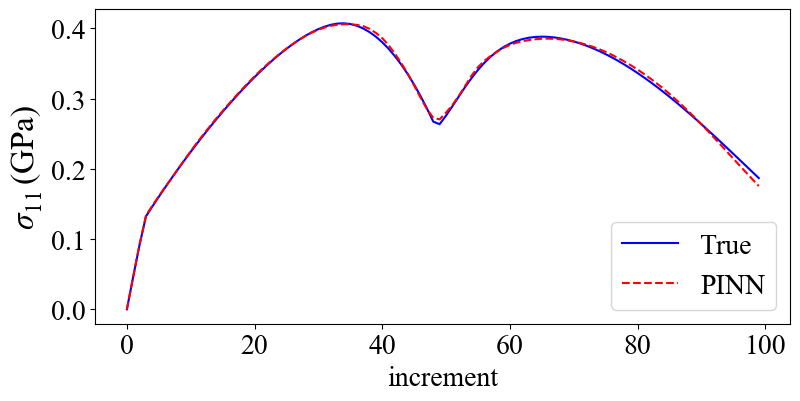

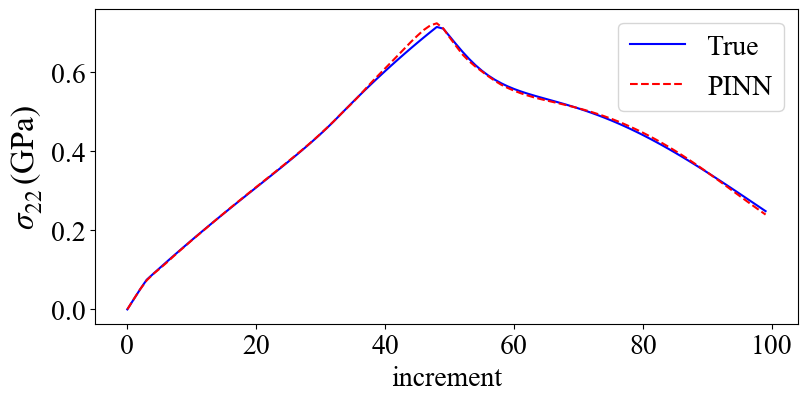

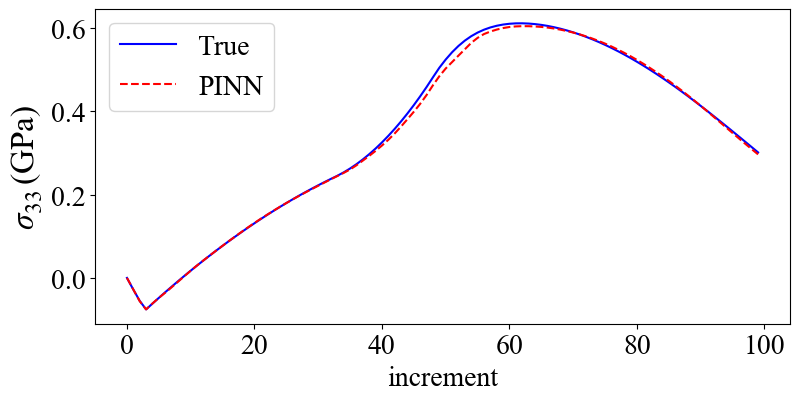

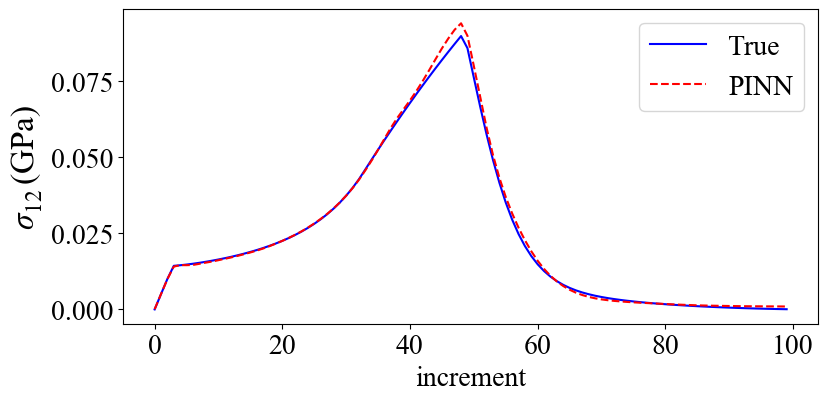

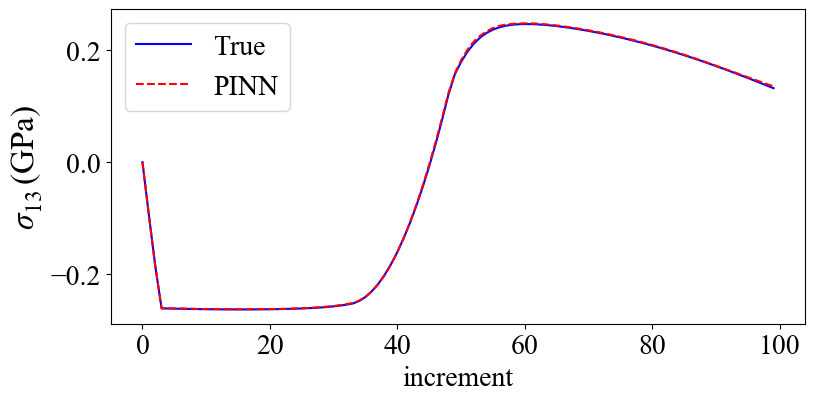

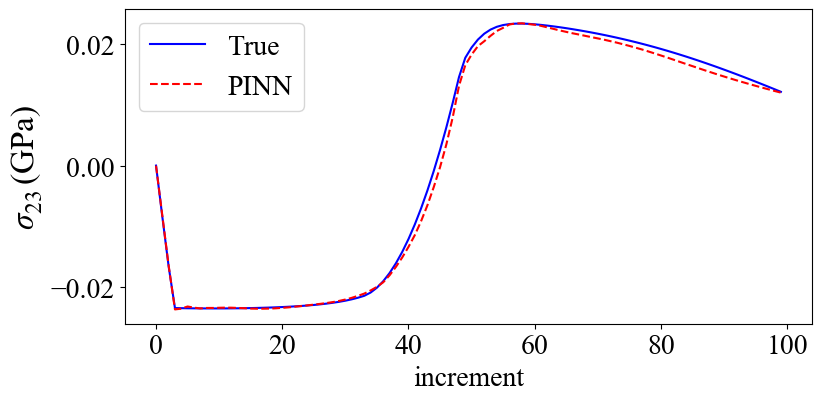

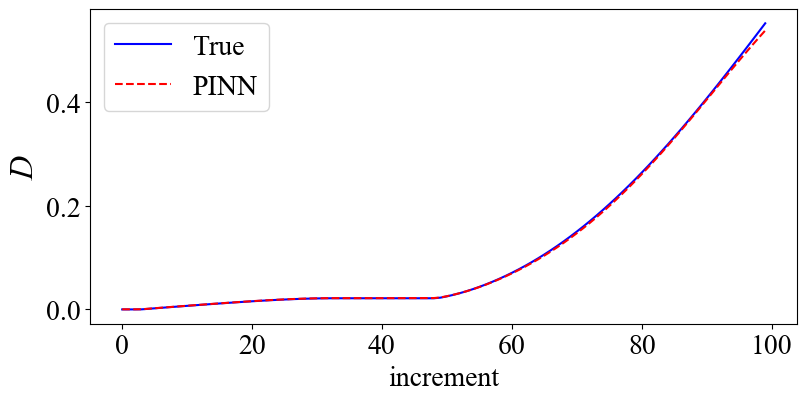

In [7]:
#  Inference inside trained domain

import matplotlib.pyplot as plt
save_path_plot_default = r"D:\Python\vsCode\PINN-review\plots_default"


model.eval()

# Pick a sample from test data
sample_index = random.randint(1,np.shape(X_test_tens)[0]-1)
x_input =  X_test_tens[sample_index].unsqueeze(0).to(device)  # Shape: (1, T, 7)
y_target = Y_test_tens[sample_index].cpu().numpy()           # Shape: (T, 7)

print('sample_index = ' , sample_index)
print(  'input = ', x_input[0][-1])
print( 'target = ', y_target[-1,:])

#%matplotlib inline

# model prediction
with torch.no_grad():
    y_pred = model(x_input)  # Shape: (1, T, 7)
    y_pred = y_pred.squeeze(0).cpu().numpy()  # Shape: (T, 7)

# back shear components to GPa
y_target[: , 3:6 ] /= 10
y_pred[: , 3:6 ] /= 10

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
plt.rcParams['font.family'] = 'Times New Roman'


labels = [r'$\sigma_{11}\,(\mathrm{GPa})$', r'$\sigma_{22}\,(\mathrm{GPa})$', r'$\sigma_{33}\,(\mathrm{GPa})$', r'$\sigma_{12}\,(\mathrm{GPa})$', r'$\sigma_{13}\,(\mathrm{GPa})$', r'$\sigma_{23}\,(\mathrm{GPa})$', r'$D$']

for i in range(0,7):
    plt.figure(figsize=(8, 4))
    plt.plot(y_target[:, i], label='True', color='blue')
    plt.plot(y_pred[:, i], '--' , label='PINN', color='red')
    plt.xlabel('increment', fontname='Times New Roman', fontsize=20)
    plt.ylabel(labels[i] , fontname='Times New Roman', fontsize=24)
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.tick_params(axis='both', labelsize=20)
    filename = os.path.join(save_path_plot, f"plot_{i}.svg")
    #plt.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()


In [ ]:
# PINN Inference [ out of trained region (starin > 0.2) ]

model.eval()

import matplotlib.pyplot as plt

# Pick a sample from test data
sample_index = random.randint(1,np.shape(X_pinn_tens)[0])

x_input_outDoamin =  X_pinn_tens[sample_index].unsqueeze(0).to(device)  # Shape: (1, T, 6)
y_target_outDoamin = Y_pinn_tens[sample_index].cpu().numpy()           # Shape: (T, 8)

print('sample_index = ' , sample_index)
print(x_input_outDoamin[0][-1])

# model prediction
with torch.no_grad():
    y_pred_outDoamin = model(x_input_outDoamin)  # Shape: (1, T, 8)
    y_pred_outDoamin= y_pred_outDoamin.squeeze(0).cpu().numpy()  # Shape: (T, 8)


# back shear components to GPa
y_target_outDoamin[: , 3:6 ] /= 10
y_pred_outDoamin[: , 3:6 ] /= 10


plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'
plt.rcParams['font.family'] = 'Times New Roman'
labels = [r'$\sigma_{11}\,(\mathrm{GPa})$', r'$\sigma_{22}\,(\mathrm{GPa})$', r'$\sigma_{33}\,(\mathrm{GPa})$', r'$\sigma_{12}\,(\mathrm{GPa})$', r'$\sigma_{13}\,(\mathrm{GPa})$', r'$\sigma_{23}\,(\mathrm{GPa})$', r'$D$']

plt.rcParams['font.family'] = 'Times New Roman'

for i in range(7):
    plt.figure(figsize=(8, 4))
    plt.plot(y_target_outDoamin[:, i], label='True', color='blue')
    plt.plot(y_pred_outDoamin[:, i],'--', label='PINN', color='red')
    plt.xlabel('Step',fontsize=20, fontname='Times New Roman')
    plt.ylabel(labels[i],fontsize=24, fontname='Times New Roman')
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.tick_params(axis='both', labelsize=20)
    filename = os.path.join(save_path_plot, f"plot_outDoamin_{i}.svg")
    #plt.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()
    
    


#### Reload model after closing

In [2]:
import torch
import pickle
import torch.nn as nn
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm 
import matplotlib.pyplot as plt
import os


# Step 0: 
Materials = ['Steel' , 'Aluminum_AA7075_T6' , 'Aluminum_notched_bar', 'Aluminum_flat_grooved']
material = Materials[1]    #  <---- choose your material


if material == 'Steel':
    model_filename = "Model_GRU_7000Epock_PINN_Steel.pth"
    session_vars_filename = "session_vars_PINN_Steel.pkl"
    
elif material == 'Aluminum_AA7075_T6':
    model_filename = "Model_GRU_7000Epock_PINN_Aluminum_AA7075_T6.pth"
    session_vars_filename = "session_vars_PINN_Aluminum_AA7075_T6.pkl"
        
elif material == 'Aluminum_notched_bar':
    model_filename = "Model_GRU_7000Epock_PINN_Aluminum_notched_bar.pth"
    session_vars_filename = "session_vars_PINN_Aluminum_notched_bar.pkl"
    
elif material == 'Aluminum_flat_grooved':
    model_filename = "Model_GRU_7000Epock_PINN_Aluminum_grooved.pth"
    session_vars_filename = "session_vars_PINN_Aluminum_grooved.pkl"



# Step 1: Load variables
with open(session_vars_filename , 'rb') as f:
    session = pickle.load(f)

train_losses     = session['train_losses']
train_losses1    = session['train_losses1']
train_losses2    = session['train_losses2']
train_losses3    = session['train_losses3']
train_klosses1   = session['train_klosses1']
train_klosses2   = session['train_klosses2']
train_klosses3   = session['train_klosses3']
X_pinn_mod       = session['X_pinn_mod']
Y_pinn_mod       = session['Y_pinn_mod']
Y_train_mod      = session['Y_train_mod']
Y_test_mod       = session['Y_test_mod']
Y_valid_mod      = session['Y_valid_mod']
X_train_mod      = session['X_train_mod']
X_test_mod       = session['X_test_mod']
X_valid_mod      = session['X_valid_mod']
input_size       = session['input_size']
output_size      = session['output_size']
num_hidden_units = session['num_hidden_units']

print(input_size,output_size,num_hidden_units)
save_path_plot = r"D:\Python\vsCode\PINN\plots"        

# Step 2: Recreate the model
class GRUNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRUNet, self).__init__()
        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True)  # When batch_first=True, PyTorch expects input of shape: (batch_size, seq_len, input_size) so xb.shape  must be: (batch_size, 100, 6)
        self.gru2 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.gru3 = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x, _ = self.gru1(x)
        x, _ = self.gru2(x)
        x, _ = self.gru3(x)
        x = self.fc(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUNet(input_size, num_hidden_units, output_size).to(device)

# Step 3: Load weights
model.load_state_dict(torch.load( model_filename ))
model.eval()

# Step 4: make tensors
X_train_tens = torch.tensor(np.array(X_train_mod), dtype=torch.float32).transpose(1, 2)  # shape: (N, T, 6)
Y_train_tens = torch.tensor(np.array(Y_train_mod), dtype=torch.float32).transpose(1, 2)  # shape: (N, T, 8)
X_test_tens  = torch.tensor(X_test_mod, dtype=torch.float32).to(device).transpose(1, 2)  # NumPy array ----> PyTorch tensor
Y_test_tens  = torch.tensor(Y_test_mod, dtype=torch.float32).to(device).transpose(1, 2)
X_valid_tens = torch.tensor(np.array(X_valid_mod), dtype=torch.float32).transpose(1, 2)
Y_valid_tens = torch.tensor(np.array(Y_valid_mod), dtype=torch.float32).transpose(1, 2)
X_pinn_tens  = torch.tensor(np.array(X_pinn_mod), dtype=torch.float32).transpose(1, 2) 
Y_pinn_tens  = torch.tensor(np.array(Y_pinn_mod), dtype=torch.float32).transpose(1, 2)


# ** Go to Inference Cell **



7 7 600


In [54]:
# calculate RMSE
RMSE = []

X_pinn_tens_t = X_pinn_tens.clone().detach().to(device)
Y_pinn_tens_t = Y_pinn_tens.clone().detach().to(device)


for i in range(100):
    out = model(X_pinn_tens_t[i])  # (100, 7)
    err = out - Y_pinn_tens_t[i]   # (100, 7)
    mse_per_feature = torch.mean(err**2, dim=0)  # mean over time steps → shape (7,)
    rmse_per_feature = torch.sqrt(mse_per_feature)  # shape (7,)
    RMSE.append(rmse_per_feature)

# Now RMSE is a list of 100 tensors of shape (7,)
# To get RMSE per feature over the entire dataset , average over samples:
RMSE = torch.stack(RMSE)  # shape (100, 7)
final_rmse_per_feature = torch.mean(RMSE, dim=0)  # shape (7,)

print(final_rmse_per_feature)


tensor([0.0138, 0.0139, 0.0145, 0.0137, 0.0121, 0.0108, 0.0162],
       device='cuda:0', grad_fn=<MeanBackward1>)


### PINN usage

#### C3D20 element 

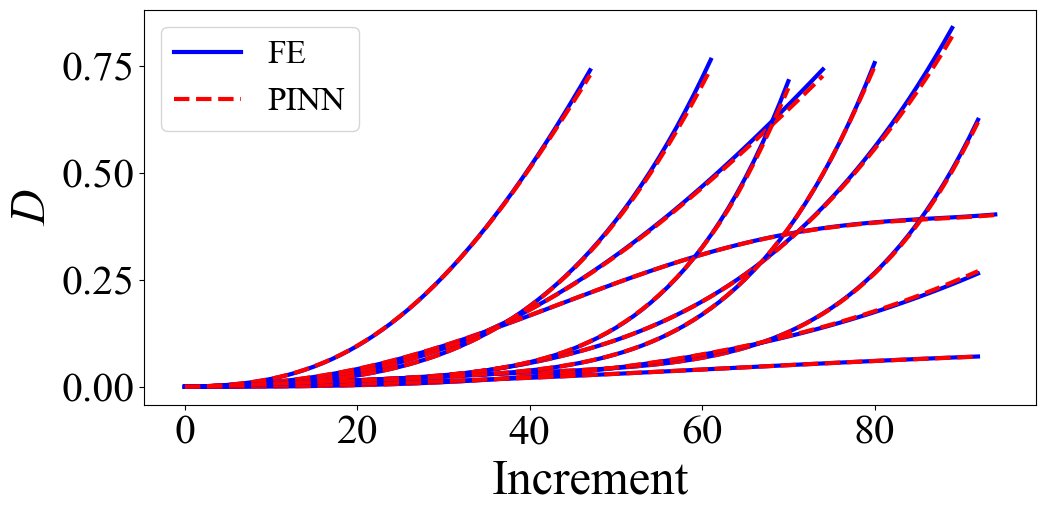

In [22]:
# for material = 'Steel'

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

labels = [r'$\sigma_{11}\,(\mathrm{GPa})$', r'$\sigma_{22}\,(\mathrm{GPa})$', r'$\sigma_{33}\,(\mathrm{GPa})$',
          r'$\sigma_{12}\,(\mathrm{GPa})$', r'$\sigma_{13}\,(\mathrm{GPa})$', r'$\sigma_{23}\,(\mathrm{GPa})$', r'$D$']

j = 6
rmse = torch.zeros(10)

plt.figure(figsize=(10, 5))

for k in range(1, 11):
    load_path = f'C:\\temp\\my_project_3\\final\\output17-{k}.xlsx'

    # Load and parse data
    X = pd.read_excel(load_path, header=None).to_numpy()
    x = X[1:-2, [6, 7, 8, 9, 11, 10, 13]].astype(float)     #careful (xx,yy,zz,xy,yz,xz)-->(xx,yy,zz,xy,xz,yz)
    x[:, -1] *= 100  # scale DLAMBDA

    yr = X[1:-2, [0, 1, 2, 3, 5, 4, 12]].astype(float)      #careful (xx,yy,zz,xy,yz,xz)-->(xx,yy,zz,xy,xz,yz)
    yr[:, 0:3] /= 1e9
    yr[:, 3:6] /= 1e8

    # cutoff fixed line
    dlam = x[:, -1]
    
    threshold = 1e-6
    valid_idx = np.where(~np.isnan(dlam))[0]
    nonzero_idx = np.where(dlam[valid_idx] > threshold)[0]
    cutoff = valid_idx[nonzero_idx[-1]] -3  # include last meaningful step

    # Slice to cutoff
    x = x[:cutoff]
    yr = yr[:cutoff]
    
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)
    ypd = model(x_tensor)
    
    if k == 1:
        plt.plot(yr[:, j], label='FE', linestyle='-', linewidth=3 , color='blue')
        plt.plot(ypd[:, j].detach().cpu().numpy(), label='PINN', linestyle='--', linewidth=3, color='red')
        
    else:
        plt.plot( yr[:, j], label='_nolegend_', linestyle='-', linewidth=3, color='blue')
        plt.plot( ypd[:, j].detach().cpu().numpy(), label='_nolegend_', linestyle='--', linewidth=3, color='red')
        
        
    yr_tensor = torch.tensor(yr, dtype=ypd.dtype, device=ypd.device)    
    rmse[k-1] = torch.sqrt(torch.mean( (yr_tensor[:, j]-ypd[:, j])**2 ))

# Finalize figure
plt.xlabel('Increment', fontsize=35, fontname='Times New Roman')
plt.ylabel(labels[j], fontsize=35, fontname='Times New Roman')
plt.legend(fontsize=24)
plt.tight_layout()


plt.tick_params(axis='both', labelsize=30)
save_path = r"D:\Python\vsCode\PINN-review\pics"    
filename = os.path.join(save_path, f"Abaqus_Element_{j}.svg")
plt.savefig(filename, format='svg', bbox_inches='tight')
plt.show()


#### Notched Bar Problem (NETO : computational methods for plasticity - example 12.4.3)  

##### Damage Contour

In [23]:
def contour_Plotter(nodes , connectivity ,Data , variable):
    
    import matplotlib.pyplot as plt
    from matplotlib.tri import Triangulation
    import numpy as np

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    plt.axis('off')

    x_all, y_all, z_all = [], [], []

    # Create triangles from each quad (2 triangles per element)
    triangles = []
    node_idx = 0

    elNum = connectivity.shape[0]
    
    for i in range(elNum):
        elemNodes = connectivity[i, 1:].astype(int)
        x = nodes[elemNodes - 1, 1]
        y = nodes[elemNodes - 1, 2]

        # Per-node scalar value
        c = np.zeros(4)
        for r in range(4):
            nd = elemNodes[r]
            rows, cols = np.where(connectivity[:, 1:] == nd)
            c[r] = np.mean(Data[rows, cols])

        for sx in [1, -1]:
            for sy in [1, -1]:
                x_m = sx * x
                y_m = sy * y
                c_m = c

                # Add node coordinates and scalar values
                for j in range(4):
                    x_all.append(x_m[j])
                    y_all.append(y_m[j])
                    z_all.append(c_m[j])

                # Two triangles: [0,1,2] and [0,2,3]
                triangles.append([node_idx, node_idx + 1, node_idx + 2])
                triangles.append([node_idx, node_idx + 2, node_idx + 3])
                node_idx += 4

    # Convert to arrays
    x_all = np.array(x_all)
    y_all = np.array(y_all)
    z_all = np.array(z_all)
    triangles = np.array(triangles)

    # Create triangulation and plot
    triang = Triangulation(x_all, y_all, triangles)
    tpc = ax.tripcolor(triang, z_all, cmap='jet', shading='gouraud', edgecolors='k')

    # Colorbar
    cbar = plt.colorbar(tpc, ax=ax)
    cbar.set_label(variable , fontsize=15)
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.show()


In [ ]:
# Predict by PINN
from Nodes_Connectivity import geometry_constructor
import pandas as pd

material = 'Steel' 
nodes , connectivity = geometry_constructor(material)


load_path_base = r'C:\temp\my_project_2_script_Bj\results_Damage_local\\'
load_path_base2 = r'C:\temp\my_project_2_script_Bj\data\F-D-Neto.xlsx'

data1_neto = pd.read_excel(load_path_base2, header=None)
displacement_neto = data1_neto.iloc[2:, 0].to_numpy().T


elNum = connectivity.shape[0]
numIntg = 4
steps = 189
Strains_neto = np.zeros((6, steps, elNum, numIntg))  # [strain_type, step, element, gauss point]
Stress_neto  = np.zeros((6, steps, elNum, numIntg))
D_neto       = np.zeros((1, steps, elNum, numIntg))
Dlanda_neto  = np.zeros((1, steps, elNum, numIntg))  
pred_Neto    = np.zeros((steps, 7, elNum, numIntg)) 

#Read strain data
strain_ids = [11, 22, 33 , 12]
for n, s in enumerate(strain_ids):  #(indx,value)
    for i in range(1, steps + 1):
        filename = os.path.join(load_path_base + f"Strain_{s}_{i}.csv")
        data_neto = np.loadtxt(filename, delimiter=',')
        Strains_neto[n, i - 1, :, :] = data_neto[:, :numIntg]  # [element, gauss_point]

#Read stress data
stress_ids = [11, 22, 33 , 12]
for n, s in enumerate(stress_ids):  #(indx,value)
    for i in range(1, steps + 1):
        filename = os.path.join(load_path_base + f"Stress_{s}_{i}.csv")
        data1_neto = np.loadtxt(filename, delimiter=',')
        Stress_neto[n, i - 1, :, :] = data1_neto[:, :numIntg]  # [element, gauss_point]

# Read D data
for i in range(1, steps + 1):
    filename = os.path.join(load_path_base + f"Damage_{i}.csv")
    data2_neto = np.loadtxt(filename, delimiter=',')
    D_neto[0, i - 1, :, :] = data2_neto[:, :numIntg]  # [element, gauss_point]

# Read Dlanda data
for i in range(1, steps + 1):
    filename = os.path.join(load_path_base + f"Dlanda_{i}.csv")
    data3_neto = np.loadtxt(filename, delimiter=',') * 100
    Dlanda_neto[0, i - 1, :, :] = data3_neto[:, :numIntg]  # [element, gauss_point]


Strains_neto = np.concatenate((Strains_neto, Dlanda_neto), axis=0)


# Predict
for e in range(elNum):
    for g in range(numIntg):
        strain_input = torch.tensor(Strains_neto[:, :, e, g].T, dtype=torch.float32).to(device)  # [steps, 6]
        pred_Neto[:, : ,e , g ] = model(strain_input).detach().cpu().numpy()  # Model_GRU_7000Epock_PINN_Steel


contour_Plotter(nodes , connectivity ,pred_Neto[-1,6,:,:] , 'Damage')

print('D_Max_Pred_Neto = ' , np.max(pred_Neto[-1,6,:,:]))l

In [ ]:
# As no suitable Python library was available for rendering gradient colors on quadrilaterals,
# Consequently, we ended up using MATLAB to obtain higher-quality visualizations.

In [ ]:
# centeral Elemnt (compaire to Neto)

# for material = 'Steel'


import numpy as np
import pandas as pd
save_path_plot_default = r"D:\Python\vsCode\PINN\plots_default"

#from Neto Book to compaire
BookNeto_U = [0.004, 0.030, 0.049, 0.073, 0.100, 0.136, 0.179, 0.216, 0.246, 0.273, 0.309, 0.345, 0.375, 0.400, 0.436, 0.451, 0.477, 0.497, 0.513, 0.531, 0.546, 0.557, 0.564, 0.572, 0.576]
BookNeto_D = [0.000, 0.002, 0.002, 0.008, 0.017, 0.036, 0.061, 0.080, 0.106, 0.129, 0.154, 0.188, 0.215, 0.238, 0.278, 0.301, 0.336, 0.380, 0.415, 0.464, 0.512, 0.568, 0.614, 0.685, 1.000]

plt.figure(figsize=(10, 7))
plt.plot(BookNeto_U ,BookNeto_D ,  linestyle='--', linewidth=2.5, color='blue', label='de Souza Neto et al., 2008 - (Nodal value)') #, 'bo-', markersize=3

# CE=centeral element
CE_ElNum = 6
CE_IntgNum = 2
starin_CE = Strains_neto[:, :, CE_ElNum-1, CE_IntgNum-1].T 
strain_CE_input = torch.tensor(starin_CE, dtype=torch.float32).to(device)
pred_Neto_CE = model(strain_CE_input).detach().cpu().numpy()  # Model_GRU_7000Epock_PINN_Steel


# true values
stress_CE_tr = Stress_neto[:, :, CE_ElNum-1, CE_IntgNum-1].T
stress_CE_tr[: , 0:3] /= 1e9
stress_CE_tr[: , 3:6] /= 1e8
damage_CE_tr = D_neto[:, :, CE_ElNum-1, CE_IntgNum-1].T 


plt.plot(displacement_neto , pred_Neto_CE[:,-1],  linestyle='-', linewidth=2.5, color='red', label='PINN - (Gauss point value)')
plt.plot(displacement_neto , damage_CE_tr,  linestyle='-', linewidth=2.5, color='green', label='FE - (Gauss point value)')
plt.xlabel('Edge Displacement (mm)', fontsize=26, fontname='Times New Roman')
plt.ylabel('Damage', fontsize=32, fontname='Times New Roman')
plt.legend(prop={'family': 'Times New Roman', 'size': 25})
plt.tight_layout()
plt.xticks(fontname='Times New Roman', fontsize=26)
plt.yticks(fontname='Times New Roman', fontsize=26)
plt.tick_params(axis='both', labelsize=26)
filename = os.path.join(save_path_plot_default, f"Neto_1.svg")
#plt.savefig(filename, format='svg', bbox_inches='tight')
#plt.savefig('D-U-Neto.svg', format='svg', bbox_inches='tight')



In [ ]:
#Damage error - (PINN compaire to FE)

# pred_Neto.shape is (189, 7, 612, 4)
# D_neto.shape    is (1, 189, 612, 4)
# error_damage.shape is (1,612, 4)

i=10
while (i< displacement_neto.shape[0]) :

    displacement_neto[i]
    
    error_damage = D_neto[:,i,:,:] -  pred_Neto[i,6,:,:]
    
    
    contour_Plotter(nodes , connectivity , error_damage[0], 'Damage Error')

    print('Max_Error_D = ' , np.max(error_damage))
    print('U       = ' , displacement_neto[i] , '[mm]' )
    
    i += 70

In [50]:
# plot in Matlab for better quality

import scipy.io
scipy.io.savemat('Neto_pred.mat', {'Neto_pred': pred_Neto})
scipy.io.savemat('Neto_D.mat', {'Neto_D': D_neto})
scipy.io.savemat('Neto_nodes.mat', {'Neto_nodes': nodes})
scipy.io.savemat('Neto_connectivity.mat', {'Neto_connectivity': connectivity})
scipy.io.savemat('Neto_displacement.mat', {'Neto_displacement': displacement_neto})

#### Nonlocal distribution

In [2]:
def calculate_integration_points_posistion_2D(nodes, connectivity):
    # for 8-node element with 4 integration points
    
    # Gauss quadrature points
    gauss_points = np.array([
        [-1/np.sqrt(3), -1/np.sqrt(3)],
        [ 1/np.sqrt(3), -1/np.sqrt(3)],
        [ 1/np.sqrt(3),  1/np.sqrt(3)],
        [-1/np.sqrt(3),  1/np.sqrt(3)]
    ])
    
    # Create node dictionary for fast lookup
    node_dict = {int(node[0]): (node[1], node[2]) for node in nodes}
    
    n_elements = connectivity.shape[0]
    n_points_per_element = 4
    
    # Precompute shape functions for all Gauss points
    def shape_functions_all():
        N_all = []
        for xi, eta in gauss_points:
            N = np.zeros(8)
            N[0] = 0.25 * (1 - xi) * (1 - eta) * (-xi - eta - 1)
            N[1] = 0.25 * (1 + xi) * (1 - eta) * (xi - eta - 1)
            N[2] = 0.25 * (1 + xi) * (1 + eta) * (xi + eta - 1)
            N[3] = 0.25 * (1 - xi) * (1 + eta) * (-xi + eta - 1)
            N[4] = 0.5 * (1 - xi**2) * (1 - eta)
            N[5] = 0.5 * (1 + xi) * (1 - eta**2)
            N[6] = 0.5 * (1 - xi**2) * (1 + eta)
            N[7] = 0.5 * (1 - xi) * (1 - eta**2)
            N_all.append(N)
        return np.array(N_all)
    
    N_all = shape_functions_all()
    
    # Prepare results array
    Integration = np.zeros((n_elements * n_points_per_element, 4))
    
    for element_idx in range(n_elements):
        element_data = connectivity[element_idx]
        element_number = int(element_data[0])
        node_numbers = element_data[1:9].astype(int)
        
        # Get coordinates of element nodes
        node_coords = np.array([node_dict[node_num] for node_num in node_numbers])
        x_nodes = node_coords[:, 0]
        y_nodes = node_coords[:, 1]
        
        # Calculate all integration points for this element
        x_points = np.dot(N_all, x_nodes)
        y_points = np.dot(N_all, y_nodes)
        
        # Fill the results array
        start_idx = element_idx * n_points_per_element
        for gp_idx in range(n_points_per_element):
            point_idx = start_idx + gp_idx
            Integration[point_idx, 0] = point_idx + 1  # Integration point number
            Integration[point_idx, 1] = x_points[gp_idx]  # x-coordinate
            Integration[point_idx, 2] = y_points[gp_idx]  # y-coordinate
            Integration[point_idx, 3] = element_number  # Element number
    
    return Integration


In [3]:
def Nonloacl_Gaussian_2D(neighbourhood, Strains, Integrations, elNum , numIntg):
    
    NonLocalStrains = np.zeros((7, Strains.shape[1], elNum, numIntg))
    
    if neighbourhood == 0:
        neighbourhood = 1e-6
    

    for e in range(elNum):
        for g in range(numIntg):
            # Get the coordinates of the current integration point
            # Find the integration point that belongs to element e and is the g-th point
            integration_mask = (Integrations[:, 3] == e+1)  # Filter by element number
            integration_points_for_element = Integrations[integration_mask]    # (4*4)
            
            # Get the specific integration point (g-th point in this element)
            x_base = integration_points_for_element[g, 1]  # x-coordinate
            y_base = integration_points_for_element[g, 2]  # y-coordinate
            
            I = []  # This will now store integration point indices
            n = 0
            
            # Find all integration points within the neighbourhood
            for i in range(Integrations.shape[0]):
                x_check = Integrations[i, 1]
                y_check = Integrations[i, 2]
                r = np.sqrt((x_base - x_check)**2 + (y_base - y_check)**2)
                if r <= neighbourhood:
                    I.append(i)
                    n += 1
            
            strainSum = np.zeros((7, Strains.shape[1]))
            weightSum = 0
            
            # k = index of integration point within neighbourhood
            for k in I:   # I = included integration points
                x_check = Integrations[k, 1]
                y_check = Integrations[k, 2]
                r = np.sqrt((x_base - x_check)**2 + (y_base - y_check)**2)
                w = (1 - (r**2) / (neighbourhood**2))**2
                
                # Get the element and integration point index from the integration point number
                integration_point_element = int(Integrations[k, 3])  # Element number  
                              
                integration_mask_x = (Integrations[:, 3] == integration_point_element)  # Filter by element number
                integration_points_for_element_x = Integrations[integration_mask_x]    # (4*4)

                integration_point_number = Integrations[k, 0]
                
                # according to Abaqus Integration points numbering:
                if integration_point_number  == integration_points_for_element_x[0,0]-1:
                    integration_point_index = 0
                if integration_point_number  == integration_points_for_element_x[1,0]-1:
                    integration_point_index = 1
                if integration_point_number  == integration_points_for_element_x[2,0]-1:
                    integration_point_index = 3
                if integration_point_number  == integration_points_for_element_x[3,0]-1:
                    integration_point_index = 2
                    
                # Get the strain at this integration point
                strain = Strains[:, :, integration_point_element-1, integration_point_index]
                strainSum = strainSum + w * strain
                weightSum = weightSum + w
            
            NonLocalStrains[:, :, e, g] = strainSum / weightSum
    
    return NonLocalStrains

##### Pre Notched Bar (de Almeida César de Sá et al., 2010)

In [ ]:
import numpy as np
import pandas as pd
from Nodes_Connectivity import geometry_constructor


material = 'Aluminum_notched_bar'
Mesh = [1,2]  #[coarse, fine]

mesh = Mesh[0]  # <--- chose your mesh

nodes , connectivity = geometry_constructor(material, mesh)
elNum = connectivity.shape[0]
numIntg = 4

# read Strains
if mesh == 1:   # coarse mesh
    load_path_base = r'C:\temp\my_project_2_script_Bj_Cesar\results_Damage_local_step002_coarse\\'
    load_path_base2 = r'C:\temp\my_project_2_script_Bj_Cesar\data\F_D_Cesar_coarse.xlsx'
    steps = 501

elif mesh == 2:  # fine mesh
    load_path_base = r'C:\temp\my_project_2_script_Bj_Cesar\results_Damage_local_step002_fine\\'
    load_path_base2 = r'C:\temp\my_project_2_script_Bj_Cesar\data\F_D_Cesar_fine.xlsx'
    steps = 510

    
    
data1_cesar = pd.read_excel(load_path_base2, header=None)
displacement_cesar = data1_cesar.iloc[1:, 0].to_numpy().T


Strains_cesar   = np.zeros((6, steps, elNum, numIntg))  # [strain_type, step, element, gauss point]
Stress_cesar    = np.zeros((6, steps, elNum, numIntg))
D_cesar         = np.zeros((1, steps, elNum, numIntg))
Dlanda_cesar    = np.zeros((1, steps, elNum, numIntg))  
pred_local_cesar = np.zeros((steps, 7, elNum, numIntg)) 

#Read strain data
strain_ids = [11, 22, 33 , 12]
for n, s in enumerate(strain_ids):  #(indx,value)
    for i in range(1, steps + 1):
        filename = os.path.join(load_path_base + f"Strain_{s}_{i}.csv")
        data = np.loadtxt(filename, delimiter=',')
        Strains_cesar[n, i - 1, :, :] = data[:, :numIntg]  # [element, gauss_point]

#Read stress data
stress_ids = [11, 22, 33 , 12]
for n, s in enumerate(stress_ids):  #(indx,value)
    for i in range(1, steps + 1):
        filename = os.path.join(load_path_base + f"Stress_{s}_{i}.csv")
        data1_cesar = np.loadtxt(filename, delimiter=',')
        Stress_cesar[n, i - 1, :, :] = data1_cesar[:, :numIntg]  # [element, gauss_point]

# Read D data
for i in range(1, steps + 1):
    filename = os.path.join(load_path_base + f"Damage_{i}.csv")
    data2_cesar = np.loadtxt(filename, delimiter=',')
    D_cesar[0, i - 1, :, :] = data2_cesar[:, :numIntg]  # [element, gauss_point]    
        

# Read Dlanda
for i in range(1, steps + 1):
    filename = os.path.join(load_path_base + f"Dlanda_{i}.csv")
    data2 = np.loadtxt(filename, delimiter=',') *100
    Dlanda_cesar[0, i - 1, :, :] = data2[:, :numIntg]  # [element, gauss_point]


Strains_cesar  = np.concatenate((Strains_cesar, Dlanda_cesar), axis=0)


# local Cesar
for e in range(elNum):  # element
    for g in range(numIntg):  # integ point
        strain_input_cesar = torch.tensor(Strains_cesar[:, :, e, g].T, dtype=torch.float32).to(device)  # [steps, 6]
        pred_local_cesar[:, : ,e , g ]   = model(strain_input_cesar).detach().cpu().numpy() # Model_GRU_7000Epock_PINN_Aluminum_notched_bar


contour_Plotter(nodes , connectivity ,pred_local_cesar[-1,6,:,:] , 'Damage')

print('D_Pred_Max_final_local_cesar = ' , np.max(pred_local_cesar[-1,6,:,:]))


# pred_local_cesar --> (steps, 7, elNum, numIntg)


In [16]:
# plot in Matlab for better quality
# coarse mesh

import scipy.io
scipy.io.savemat('Cesar1_pred_local.mat',   {'Cesar1_pred_local': pred_local_cesar})
scipy.io.savemat('Cesar1_D.mat',            {'Cesar1_D': D_cesar})
scipy.io.savemat('Cesar1_nodes.mat',        {'Cesar1_nodes': nodes})
scipy.io.savemat('Cesar1_connectivity.mat', {'Cesar1_connectivity': connectivity})
scipy.io.savemat('Cesar1_displacement.mat', {'Cesar1_displacement': displacement_cesar})

In [13]:
# fine mesh

import scipy.io
scipy.io.savemat('Cesar2_pred_local.mat',   {'Cesar2_pred_local': pred_local_cesar})
scipy.io.savemat('Cesar2_D.mat',            {'Cesar2_D': D_cesar})
scipy.io.savemat('Cesar2_nodes.mat',        {'Cesar2_nodes': nodes})
scipy.io.savemat('Cesar2_connectivity.mat', {'Cesar2_connectivity': connectivity})
scipy.io.savemat('Cesar2_displacement.mat', {'Cesar2_displacement': displacement_cesar})

In [ ]:
#Damage error local- (PINN compaire to FE)

i=10
while (i< displacement_cesar.shape[0]) :

    displacement_cesar[i]
    error_damage = D_cesar[:,i,:,:] -  pred_local_cesar[i,6,:,:]
    contour_Plotter(nodes , connectivity , error_damage[0] , 'Damage Error')
    print('Max Error_D = ' , np.max(error_damage))
    print('U       = ' , displacement_cesar[i] , '[mm]' )
    i += 90

In [ ]:
# nonlocal Cesar
# Apply nonlocal Gaussian smoothing on Strains

NonlocalStrain_cesar = np.zeros((7, Strains_cesar.shape[1], elNum, numIntg))
pred_nonlocal_cesar = np.zeros((steps, 7, elNum, numIntg)) 

neighbourhood = 0.1 # [mm]  [0.6325, 0.8, 1.0]

Integrations_cesar = calculate_integration_points_posistion_2D(nodes, connectivity)



NonlocalStrain_cesar = Nonloacl_Gaussian_2D(neighbourhood, Strains_cesar, Integrations_cesar, elNum, numIntg)


for e in range(elNum):  # element
    for g in range(numIntg):  # integ point
        strain_input_cesar = torch.tensor(NonlocalStrain_cesar[:, :, e, g].T, dtype=torch.float32).to(device)  # [steps, 6]
        pred_nonlocal_cesar[:, : ,e , g ] = model(strain_input_cesar).detach().cpu().numpy() # Model_GRU_7000Epock_PINN_Aluminum_notched_bar

        

contour_Plotter(nodes , connectivity ,pred_nonlocal_cesar[-1,6,:,:] , 'Nonlocal Damage')

print('D_Pred_final_nonlocal_cesar = ' , np.max(pred_nonlocal_cesar[-1,6,:,:]))
print('Lr = ' , neighbourhood , ' [mm]')


In [88]:
# Nonlocal coarse mesh

import scipy.io
scipy.io.savemat('Cesar2_pred_Nonlocal_Lr6325.mat',   {'Cesar2_pred_Nonlocal_Lr6325': pred_nonlocal_cesar})

##### Double Notch Ranjbar (related to 'http://dx.doi.org/10.1016/j.ijmecsci.2017.05.008')

In [3]:
def calculate_integration_points_position_C3D20(nodes, connectivity):
    """
    Calculate integration points positions for C3D20 element (20-node brick element)
    
    Parameters:
    nodes: array of nodes with format [node_id, x, y, z]
    connectivity: array of element connectivity with format [element_id, node1, node2, ..., node20]
    
    Returns:
    Integration: array with format [point_id, x, y, z, element_id]
    """
    
    # Gauss quadrature points for 2x2x2 integration (8 points)
    g = 1.0 / np.sqrt(3.0)
    gauss_points = np.array([
        [-g, -g, -g],
        [ g, -g, -g],
        [ g,  g, -g],
        [-g,  g, -g],
        [-g, -g,  g],
        [ g, -g,  g],
        [ g,  g,  g],
        [-g,  g,  g]
    ])
    
    # Create node dictionary for fast lookup
    node_dict = {int(node[0]): (node[1], node[2], node[3]) for node in nodes}
    
    n_elements = connectivity.shape[0]
    n_points_per_element = 8
    
    # Precompute shape functions for all Gauss points
    def shape_functions_all():
        N_all = []
        for xi, eta, zeta in gauss_points:
            N = np.zeros(20)
            
            # Corner nodes (1-8)
            N[0] = 0.125 * (1 - xi) * (1 - eta) * (1 - zeta) * (-xi - eta - zeta - 2)
            N[1] = 0.125 * (1 + xi) * (1 - eta) * (1 - zeta) * (xi - eta - zeta - 2)
            N[2] = 0.125 * (1 + xi) * (1 + eta) * (1 - zeta) * (xi + eta - zeta - 2)
            N[3] = 0.125 * (1 - xi) * (1 + eta) * (1 - zeta) * (-xi + eta - zeta - 2)
            N[4] = 0.125 * (1 - xi) * (1 - eta) * (1 + zeta) * (-xi - eta + zeta - 2)
            N[5] = 0.125 * (1 + xi) * (1 - eta) * (1 + zeta) * (xi - eta + zeta - 2)
            N[6] = 0.125 * (1 + xi) * (1 + eta) * (1 + zeta) * (xi + eta + zeta - 2)
            N[7] = 0.125 * (1 - xi) * (1 + eta) * (1 + zeta) * (-xi + eta + zeta - 2)
            
            # Mid-edge nodes (9-20)
            # Bottom face (z = -1)
            N[8] = 0.25 * (1 - xi*xi) * (1 - eta) * (1 - zeta)
            N[9] = 0.25 * (1 + xi) * (1 - eta*eta) * (1 - zeta)
            N[10] = 0.25 * (1 - xi*xi) * (1 + eta) * (1 - zeta)
            N[11] = 0.25 * (1 - xi) * (1 - eta*eta) * (1 - zeta)
            
            # Top face (z = 1)
            N[12] = 0.25 * (1 - xi*xi) * (1 - eta) * (1 + zeta)
            N[13] = 0.25 * (1 + xi) * (1 - eta*eta) * (1 + zeta)
            N[14] = 0.25 * (1 - xi*xi) * (1 + eta) * (1 + zeta)
            N[15] = 0.25 * (1 - xi) * (1 - eta*eta) * (1 + zeta)
            
            # Middle layer
            N[16] = 0.25 * (1 - xi) * (1 - eta) * (1 - zeta*zeta)
            N[17] = 0.25 * (1 + xi) * (1 - eta) * (1 - zeta*zeta)
            N[18] = 0.25 * (1 + xi) * (1 + eta) * (1 - zeta*zeta)
            N[19] = 0.25 * (1 - xi) * (1 + eta) * (1 - zeta*zeta)
            
            N_all.append(N)
        return np.array(N_all)
    
    N_all = shape_functions_all()
    
    # Prepare results array: [point_id, x, y, z, element_id]
    Integration = np.zeros((n_elements * n_points_per_element, 5))
    
    for element_idx in range(n_elements):
        element_data = connectivity[element_idx]
        element_number = int(element_data[0])
        node_numbers = element_data[1:21].astype(int)  # 20 nodes per element
        
        # Get coordinates of element nodes
        node_coords = np.array([node_dict[node_num] for node_num in node_numbers])
        x_nodes = node_coords[:, 0]
        y_nodes = node_coords[:, 1]
        z_nodes = node_coords[:, 2]
        
        # Calculate all integration points for this element
        x_points = np.dot(N_all, x_nodes)
        y_points = np.dot(N_all, y_nodes)
        z_points = np.dot(N_all, z_nodes)
        
        # Fill the results array
        start_idx = element_idx * n_points_per_element
        for gp_idx in range(n_points_per_element):
            point_idx = start_idx + gp_idx
            Integration[point_idx, 0] = point_idx + 1  # Integration point number
            Integration[point_idx, 1] = x_points[gp_idx]  # x-coordinate
            Integration[point_idx, 2] = y_points[gp_idx]  # y-coordinate
            Integration[point_idx, 3] = z_points[gp_idx]  # z-coordinate
            Integration[point_idx, 4] = element_number  # Element number
    
    return Integration

In [4]:
def Nonlocal_Gaussian_3D(neighbourhood, Strains, Integrations, elNum, numIntg):
    """
    3D Non-local Gaussian strain calculation
    
    Parameters:
    neighbourhood: float - search radius for non-local averaging
    Strains: 4D array - strain tensor data [strain_components, time_steps, elements, integration_points]
    Integrations: 2D array - integration point data [point_id, x, y, z, element_number]
    elNum: int - number of elements
    numIntg: int - number of integration points per element
    
    Returns:
    NonLocalStrains: 4D array - non-local averaged strains
    """
    if neighbourhood == 0:
        neighbourhood = 1e-6
    
    NonLocalStrains = np.zeros((7, Strains.shape[1], elNum, numIntg))
    

    for e in range(elNum):
        for g in range(numIntg):
            # Get the coordinates of the current integration point
            # Find the integration point that belongs to element e and is the g-th point
            integration_mask = (Integrations[:, 4] == e+1)  # Filter by element number (4th column)
            integration_points_for_element = Integrations[integration_mask]    # Integration points for this element
            
            # Get the specific integration point (g-th point in this element)
            x_base = integration_points_for_element[g, 1]  # x-coordinate
            y_base = integration_points_for_element[g, 2]  # y-coordinate
            z_base = integration_points_for_element[g, 3]  # z-coordinate (new for 3D)
            
            I = []  # This will store integration point indices within neighbourhood
            n = 0
            
            # Find all integration points within the 3D neighbourhood
            for i in range(Integrations.shape[0]):
                x_check = Integrations[i, 1]
                y_check = Integrations[i, 2]
                z_check = Integrations[i, 3]
                
                # Calculate 3D Euclidean distance
                r = np.sqrt((x_base - x_check)**2 + 
                           (y_base - y_check)**2 + 
                           (z_base - z_check)**2)
                
                if r <= neighbourhood:
                    I.append(i)
                    n += 1
            
            strainSum = np.zeros((7, Strains.shape[1]))
            weightSum = 0
            
            # Process each integration point within the neighbourhood
            for k in I:   # I = included integration points
                x_check = Integrations[k, 1]
                y_check = Integrations[k, 2]
                z_check = Integrations[k, 3]
                
                # Calculate 3D distance
                r = np.sqrt((x_base - x_check)**2 + 
                           (y_base - y_check)**2 + 
                           (z_base - z_check)**2)
                
                # 3D Gaussian weight function
                w = (1 - (r**2) / (neighbourhood**2))**2
                
                # Get the element and integration point index
                integration_point_element = int(Integrations[k, 4])  # Element number (4th column)
                
                integration_mask_x = (Integrations[:, 4] == integration_point_element)  # Filter by element number
                integration_points_for_element_x = Integrations[integration_mask_x]    # Integration points for target element

                integration_point_number = Integrations[k, 0]
                
                
                # Example for 8-node brick element with 8 integration points
                # base on Abaqus integration point numbering algorithm: https://classes.engineering.wustl.edu/2009/spring/mase5513/abaqus/docs/v6.6/books/usb/default.htm?startat=pt06ch22s01alm01.html  Title:Numbering of integration points for output
                # according to Abaqus Integration points numbering:
                if integration_point_number  == integration_points_for_element_x[0,0]-1:
                    integration_point_index = 0
                if integration_point_number  == integration_points_for_element_x[1,0]-1:
                    integration_point_index = 1
                if integration_point_number  == integration_points_for_element_x[2,0]-1:
                    integration_point_index = 3
                if integration_point_number  == integration_points_for_element_x[3,0]-1:
                    integration_point_index = 2
                if integration_point_number  == integration_points_for_element_x[4,0]-1:
                    integration_point_index = 4
                if integration_point_number  == integration_points_for_element_x[5,0]-1:
                    integration_point_index = 5
                if integration_point_number  == integration_points_for_element_x[6,0]-1:
                    integration_point_index = 7
                if integration_point_number  == integration_points_for_element_x[7,0]-1:
                    integration_point_index = 6
                
                # Get the strain at this integration point
                strain = Strains[:, :, integration_point_element-1, integration_point_index]
                strainSum = strainSum + w * strain
                weightSum = weightSum + w
            
            # Avoid division by zero
            if weightSum > 1e-10:
                NonLocalStrains[:, :, e, g] = strainSum / weightSum
            else:
                # Use local strain if no neighbors found
                NonLocalStrains[:, :, e, g] = Strains[:, :, e, g]
    
    return NonLocalStrains

In [5]:
# read data

from Nodes_Connectivity import geometry_constructor
material = 'Aluminum_AA7075_T6'
nodes , connectivity = geometry_constructor(material)

load_path_base = r'C:\temp\my_project_5_Nonlocal_Ranjbar\results_Damage_local_step003\\'
elNum = connectivity.shape[0]
steps = 334
numIntg = 8  # for C3D20R


Strains_DN = np.zeros((6, steps, elNum, numIntg))  # [strain_type, step, element, gauss point]
Stress_DN  = np.zeros((6, steps, elNum, numIntg))
D_DN       = np.zeros((1, steps, elNum, numIntg))
Dlanda_DN  = np.zeros((1, steps, elNum, numIntg))  
pred_nonlocal_DN    = np.zeros((steps, 7, elNum, numIntg)) 
NonlocalStrain_DN = np.zeros((7, Strains_DN.shape[1], elNum, numIntg))


#Read strain data
strain_ids = [11, 22, 33 , 12 , 13 , 23]
for n, s in enumerate(strain_ids):  #(indx,value)
    for i in range(1, steps + 1):
        filename = os.path.join(load_path_base + f"Strain_{s}_{i}.csv")
        data_DN = np.loadtxt(filename, delimiter=',')
        Strains_DN[n, i - 1, :, :] = data_DN[:, :numIntg]  # [element, gauss_point]

#Read stress data
stress_ids = [11, 22, 33 , 12 , 13 , 23]
for n, s in enumerate(stress_ids):  #(indx,value)
    for i in range(1, steps + 1):
        filename = os.path.join(load_path_base + f"Stress_{s}_{i}.csv")
        data1_DN = np.loadtxt(filename, delimiter=',')
        Stress_DN[n, i - 1, :, :] = data1_DN[:, :numIntg]  # [element, gauss_point]

# Read D data
for i in range(1, steps + 1):
    filename = os.path.join(load_path_base + f"Damage_{i}.csv")
    data2_DN = np.loadtxt(filename, delimiter=',')
    D_DN[0, i - 1, :, :] = data2_DN[:, :numIntg]  # [element, gauss_point]

# Read Dlanda data
for i in range(1, steps + 1):
    filename = os.path.join(load_path_base + f"Dlanda_{i}.csv")
    data3_DN = np.loadtxt(filename, delimiter=',') * 100
    Dlanda_DN[0, i - 1, :, :] = data3_DN[:, :numIntg]  # [element, gauss_point]


Strains_DN = np.concatenate((Strains_DN, Dlanda_DN), axis=0)


In [ ]:
# Local

#%matplotlib widget
#matplotlib inline

# material = 'Aluminum_AA7075_T6'
import pandas as pd
import numpy as np

plt.cla()
plt.figure(figsize=(12, 6))

# FE local
indx_crtitical_Elmnt = 3
indx_crtitical_Elmnt_Intg = 2
load_path_DN = r'C:\temp\my_project_5_Nonlocal_Ranjbar\data\F-U.xlsx'
data_DN = pd.read_excel(load_path_DN, header=None).to_numpy()
end_indx = 335
U2U3_DN          = data_DN[1:end_indx,0]
U_edge_DN        = data_DN[1:end_indx,2]
damage_DN_Crit   = D_DN[0,:,indx_crtitical_Elmnt,indx_crtitical_Elmnt_Intg]

plt.plot(U2U3_DN , damage_DN_Crit,  linestyle='-', linewidth=2.5, color='Blue', label='FE local - (Gauss point value)')


# PINN local
strains_DN_Crit =  Strains_DN[:,:,indx_crtitical_Elmnt,indx_crtitical_Elmnt_Intg].T  #(7, 334, 638, 8)
strains_DN_Crit_tensor = torch.tensor(strains_DN_Crit, dtype=torch.float32).to(device)
pred_local_DN_Crit = model(strains_DN_Crit_tensor).detach().to('cpu')      # Model_GRU_7000Epock_PINN_Aluminum_AA7075_T6
plt.plot(U2U3_DN , pred_local_DN_Crit[:,6],  linestyle='--', linewidth=2.5, color='red', label='PINN local - (Gauss point value)')


plt.xlabel('Edge Displacement (mm)', fontsize=26, fontname='Times New Roman')
plt.ylabel('Damage', fontsize=26, fontname='Times New Roman')
plt.legend(prop={'family': 'Times New Roman', 'size': 26})
plt.tight_layout()
plt.xticks(np.arange(0, 0.7, 0.1))
plt.yticks(np.arange(0, 0.5, 0.1))
plt.xticks(fontname='Times New Roman', fontsize=26)
plt.yticks(fontname='Times New Roman', fontsize=26)
plt.tick_params(axis='both', labelsize=26)
#plt.savefig('Local_damage-Ranjbar.svg', format='svg', bbox_inches='tight')




In [7]:
# Nonlocal Double Notch

neighbourhood = 1.0   # mm

Integrations_DN = calculate_integration_points_position_C3D20(nodes, connectivity)

NonlocalStrain_DN = Nonlocal_Gaussian_3D(neighbourhood, Strains_DN, Integrations_DN,  elNum, numIntg)

# Predict
D_Net_pred_DN = np.zeros((numIntg, steps, elNum))  # [gauss_point, step, element]
for e in range(elNum):
    for g in range(numIntg):
        strain_input = torch.tensor(NonlocalStrain_DN[:, :, e, g].T, dtype=torch.float32).to(device)  # [steps, 6]
        pred_nonlocal_DN[:, : ,e , g ] = model(strain_input).detach().cpu().numpy()  # Model_GRU_7000Epock_PINN_Aluminum_AA7075_T6


In [ ]:
# Plot
plt.cla()


plt.figure(figsize=(12, 6))

# Nonlocal PINN
pred_nonlocal_DN_Crit =  pred_nonlocal_DN[:,6,indx_crtitical_Elmnt, indx_crtitical_Elmnt_Intg]
plt.plot(U2U3_DN , pred_nonlocal_DN_Crit, linestyle='--', linewidth=2.5, color='red', label='PINN nonlocal - (Guass point value)')


# FCM (Finite Cell Method) from paper
load_path_FCM = r'C:\temp\my_project_5_Nonlocal_Ranjbar\data\Ranjbar-FCM.xlsx'
data_FCM = pd.read_excel(load_path_FCM, header=None).to_numpy()
displacement_FCM = data_FCM[1:,0]
damage_FCM = data_FCM[1:,-1]
plt.plot(displacement_FCM , damage_FCM,  linestyle=':', linewidth=2.5, color='Black', label='FCM nonlocal - (Ranjbar et al., 2017)')


plt.xlabel('Edge Displacement (mm)', fontsize=26, fontname='Times New Roman')
plt.ylabel('Damage', fontsize=26,  fontname='Times New Roman')
plt.legend(prop={'family': 'Times New Roman', 'size': 26})
plt.tight_layout()
plt.xticks(fontname='Times New Roman', fontsize=17)
plt.yticks(fontname='Times New Roman', fontsize=17)
plt.xticks(np.arange(0, 0.7, 0.1))
plt.yticks(np.arange(0, 1.01, 0.2))
plt.tick_params(axis='both', labelsize=26)
plt.savefig('NonLocal_damage-Ranjbar.svg', format='svg', bbox_inches='tight')


In [76]:
import scipy.io
scipy.io.savemat('DN_pred_nonlocal.mat',   {'DN_pred_nonlocal': pred_nonlocal_DN})
scipy.io.savemat('DN_D.mat',               {'DN_D': D_DN})
scipy.io.savemat('DN_nodes.mat',           {'DN_nodes': nodes})
scipy.io.savemat('DN_connectivity.mat',    {'DN_connectivity': connectivity})
scipy.io.savemat('DN_displacement.mat',    {'DN_displacement': U2U3_DN})

THE END!       :)
2025.09.19